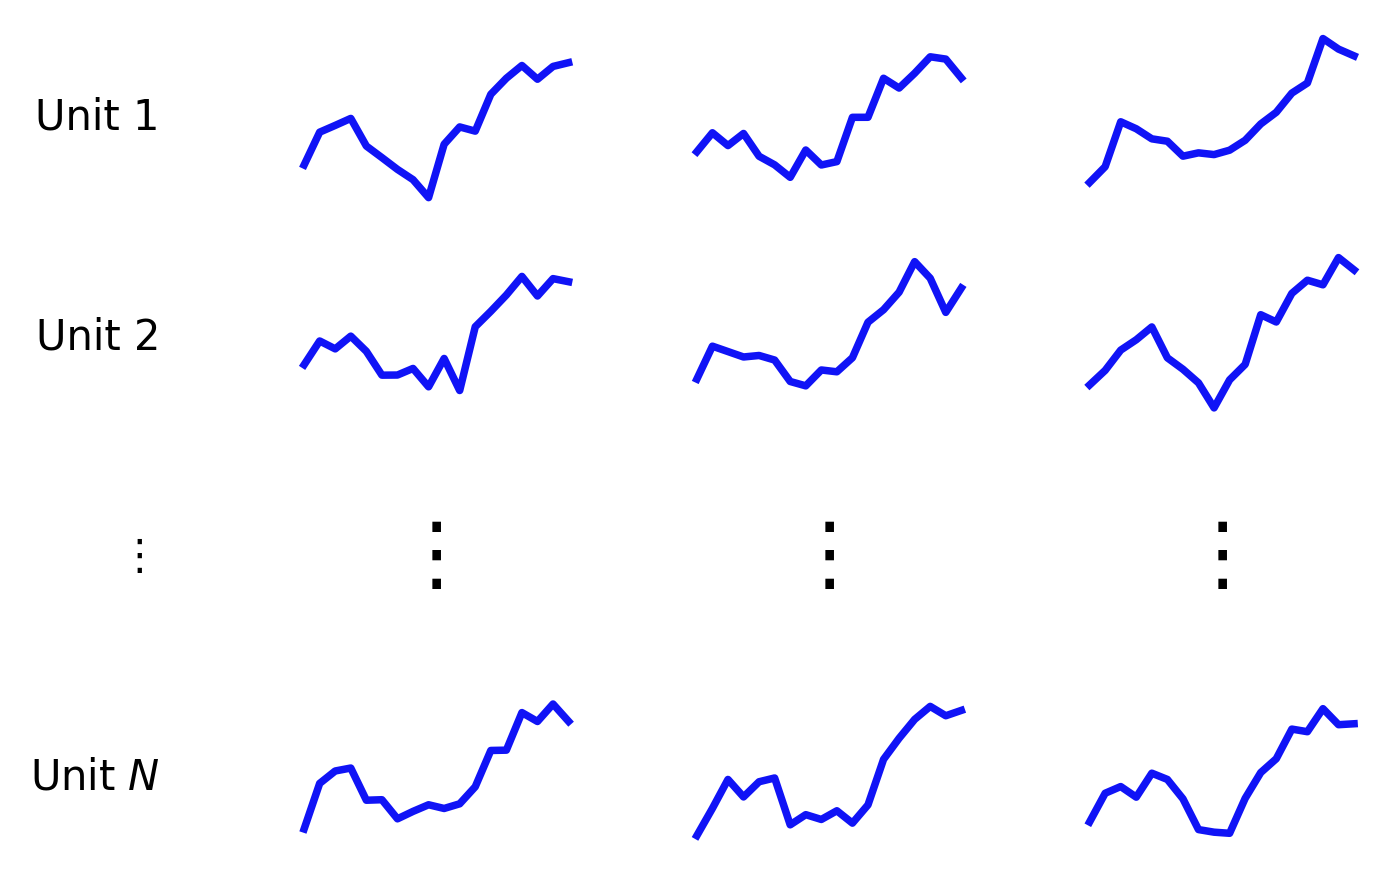

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_rows, n_cols = 4, 3
T = 18

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.6, 3.2),
    dpi=300,
    sharex=True,
    sharey=True
)

row_labels = ["Unit 1", "Unit 2", "⋮", "Unit $N$"]

for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        ax.axis("off")

        if i == 2:
            ax.text(
                0.5, 0.5, "⋮",
                ha="center",
                va="center",
                fontsize=20,
                transform=ax.transAxes
            )
        else:
            x = np.arange(T)
            trend = 0.04 * x
            seasonal = 0.25 * np.sin(x / 2 + np.random.rand() * 2)
            noise = 0.08 * np.random.randn(T)
            y = trend + seasonal + noise

            ax.plot(x, y, linewidth=1.8, color="#1013F6")

# Add row labels on the left
for i, label in enumerate(row_labels):
    axes[i, 0].text(
        -0.45, 0.5,
        label,
        ha="right",
        va="center",
        fontsize=10,
        transform=axes[i, 0].transAxes,
        clip_on=False
    )

plt.subplots_adjust(
    left=0.20,
    right=0.98,
    top=0.95,
    bottom=0.08,
    wspace=0.35,
    hspace=0.25
)

plt.show()

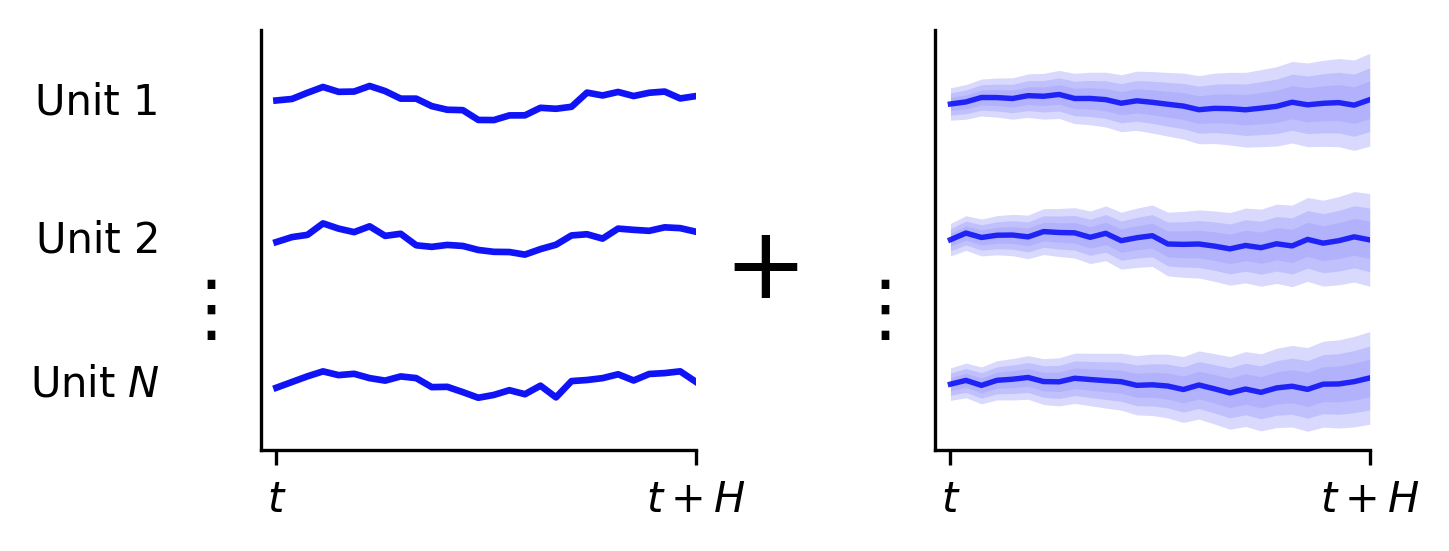

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

matlab_blue = "#1013F6"
T = 28
x = np.arange(T)

fig, axes = plt.subplots(
    1, 2,
    figsize=(4.8, 2.0),dpi=300,
    sharex=True,
    sharey=True
)

# ---------- Left: point forecasts ----------
ax = axes[0]

y_offsets = [2.2, 1.25, 0.25]
labels = ["Unit 1", "Unit 2", "Unit $N$"]

for offset, label in zip(y_offsets, labels):
    y = offset + 0.08 * np.sin(x / 3) + 0.025 * np.random.randn(T)
    ax.plot(x, y, color=matlab_blue, linewidth=1.6)

for offset, label in zip(y_offsets, labels):
    ax.text(-7.5, offset, label, ha="right", va="center", fontsize=10)

ax.text(-4.2, 0.75, "⋮", ha="center", va="center", fontsize=18)

ax.set_xlim(-1, T - 1)
ax.set_ylim(-0.2, 2.7)
ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H$"], fontsize=10)
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------- Right: quantile forecasts ----------
ax = axes[1]

for offset in y_offsets:
    center = offset + 0.04 * np.sin(x / 4) + 0.015 * np.random.randn(T)

    for k, alpha in zip([0.32, 0.22, 0.13], [0.16, 0.12, 0.08]):
        width = k * (0.35 + 0.65 * x / (T - 1))
        ax.fill_between(
            x,
            center - width,
            center + width,
            color=matlab_blue,
            alpha=alpha,
            linewidth=0
        )

    ax.plot(x, center, color=matlab_blue, linewidth=1.3, alpha=0.9)

ax.text(-4.2, 0.75, "⋮", ha="center", va="center", fontsize=18)

ax.set_xlim(-1, T - 1)
ax.set_ylim(-0.2, 2.7)
ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H$"], fontsize=10)
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ---------- Plus sign ----------
fig.text(0.55, 0.52, "+", ha="center", va="center", fontsize=24)

plt.subplots_adjust(
    left=0.20,
    right=0.97,
    bottom=0.22,
    top=0.92,
    wspace=0.55
)

plt.show()

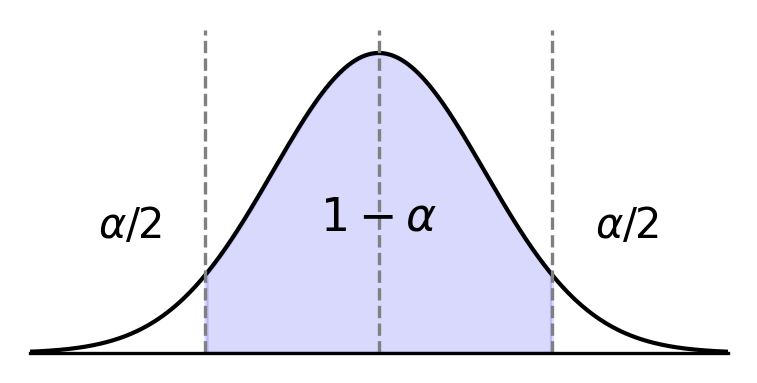

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3.5, 3.5, 500)
y = 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2)

z = 1.64   # approximately 90% interval
mask = (x >= -z) & (x <= z)

fig, ax = plt.subplots(figsize=(3.0, 1.4), dpi = 300)

ax.plot(x, y, color="black", linewidth=1.0)
ax.fill_between(x[mask], y[mask], color="#1013F6", alpha=0.16)

# Vertical dashed lines
ax.axvline(-z, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(z, color="gray", linestyle="--", linewidth=0.8)

# Text labels
ax.text(0, 0.18, r"$1-\alpha$", ha="center", va="center", fontsize=11)
ax.text(-2.35, 0.17, r"$\alpha/2$", ha="center", va="center", fontsize=10)
ax.text(2.35, 0.17, r"$\alpha/2$", ha="center", va="center", fontsize=10)

# Clean style
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(0, 0.43)
ax.set_xticks([])
ax.set_yticks([])

for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(0.8)

plt.savefig("gaussian_interval.png", dpi=300, bbox_inches="tight")
plt.show()

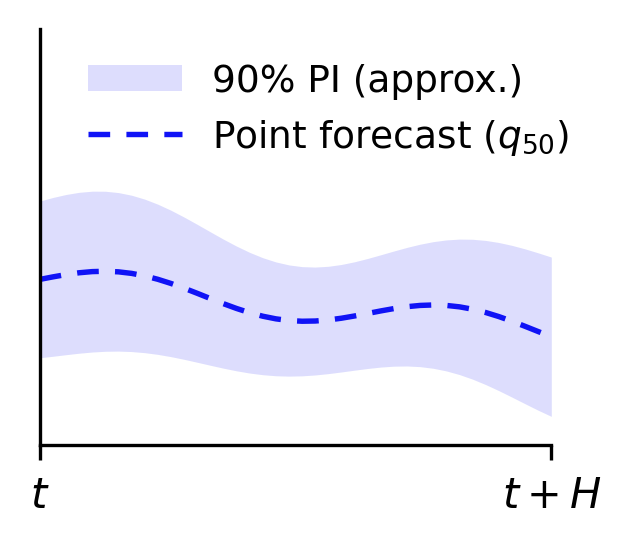

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

color = "#1013F6"
T = 40
x = np.arange(T)

mean = 0.62 - 0.003 * x + 0.035 * np.sin(x / 4)
width = 0.15 + 0.03 * np.sin(x / 6 + 1.0)

lower = mean - width
upper = mean + width

fig, ax = plt.subplots(figsize=(2.2, 1.8), dpi=300)

ax.fill_between(
    x,
    lower,
    upper,
    color=color,
    alpha=0.14,
    linewidth=0,
    label="90% PI (approx.)"
)

ax.plot(
    x,
    mean,
    color=color,
    linestyle=(0, (4, 3)),
    linewidth=1.3,
    label=r"Point forecast ($q_{50}$)"
)

ax.set_xlim(0, T - 1)
ax.set_ylim(0.25, 1.18)

ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H$"], fontsize=10)
ax.set_yticks([])

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.1, 1.0),
    frameon=False,
    fontsize=9,
    handlelength=2.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

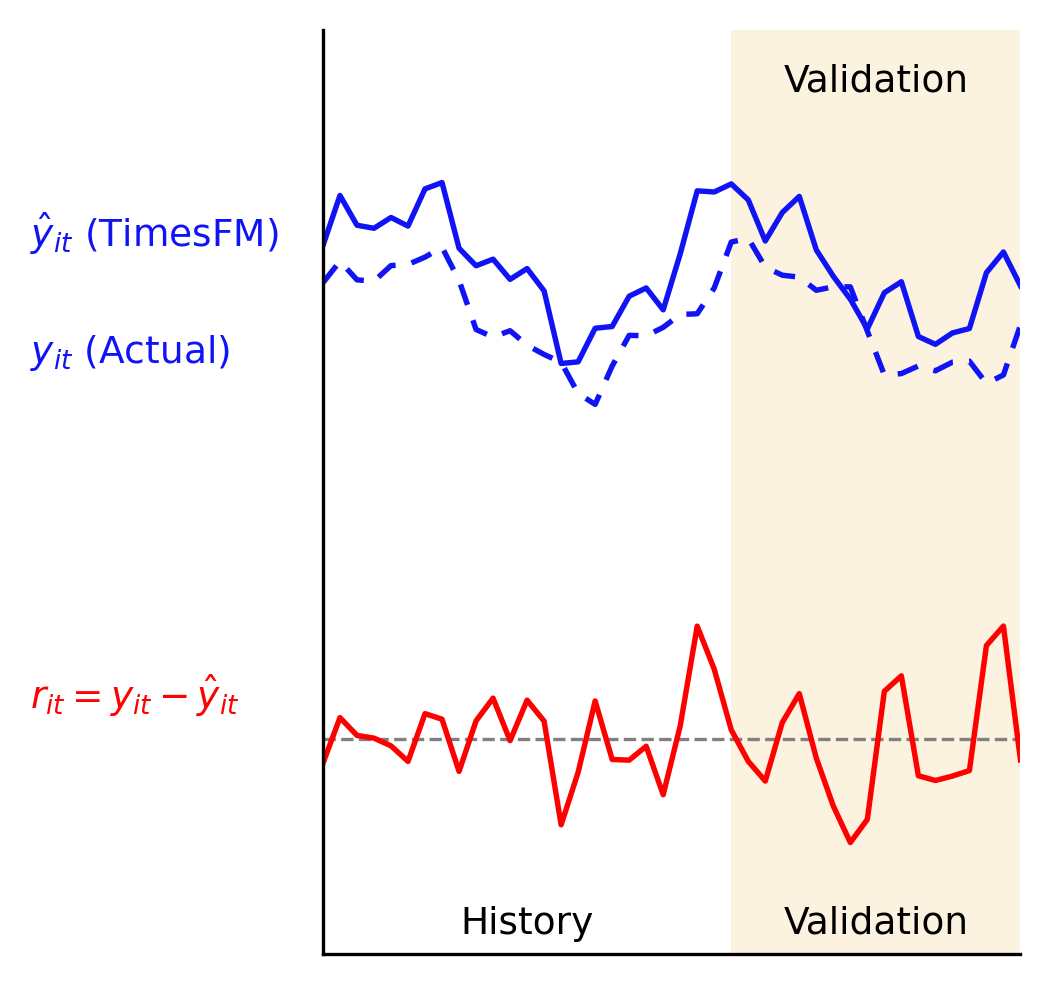

In [1]:
import numpy as np
import matplotlib.pyplot as plt

blue = "#1013F6"
red = "#FF0000"

T = 42
x = np.arange(T)
split = 24

# Actual: natural multi-frequency dynamics, no random noise
y_actual = (
    1.25
    + 0.16 * np.sin(x / 3.2)
    + 0.06 * np.sin(1.15 * x + 0.4)
    + 0.04 * np.sin(2.10 * x)
    + 0.025 * np.cos(0.55 * x)
)

# TimesFM forecast: related but imperfect counterfactual forecast
y_pred = (
    1.13
    + 0.14 * np.sin(x / 3.4 + 0.25)
    + 0.045 * np.sin(1.05 * x + 0.9)
    + 0.025 * np.sin(1.85 * x + 0.5)
)

resid = y_actual - y_pred
resid_plot = 0.15 + 1.6 * (resid - resid.mean())

fig, ax = plt.subplots(figsize=(3, 4), dpi=300)

ax.axvspan(split, T - 1, color="#F6DFA5", alpha=0.35, linewidth=0)
ax.text((split + T - 1) / 2, 1.68, "Validation", ha="center", va="center", fontsize=9)

ax.plot(x, y_actual, color=blue, linewidth=1.3)
ax.plot(x, y_pred, color=blue, linewidth=1.3, linestyle=(0, (4, 3)))

ax.axhline(0.15, color="gray", linestyle="--", linewidth=0.8)
ax.plot(x, resid_plot, color=red, linewidth=1.3)

ax.text(-0.42, 0.78, r"$\hat{y}_{it}$ (TimesFM)",
        color=blue, ha="left", va="center", fontsize=9,
        transform=ax.transAxes, clip_on=False)

ax.text(-0.42, 0.65, r"$y_{it}$ (Actual)",
        color=blue, ha="left", va="center", fontsize=9,
        transform=ax.transAxes, clip_on=False)

ax.text(-0.42, 0.28, r"$r_{it}=y_{it}-\hat{y}_{it}$",
        color=red, ha="left", va="center", fontsize=9,
        transform=ax.transAxes, clip_on=False)

ax.text(split / 2, -0.28, "History", ha="center", va="center", fontsize=9)
ax.text((split + T - 1) / 2, -0.28, "Validation", ha="center", va="center", fontsize=9)

ax.set_xlim(0, T - 1)
ax.set_ylim(-0.35, 1.8)
ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("validation_residual_panel.png", dpi=300, bbox_inches="tight")
plt.show()

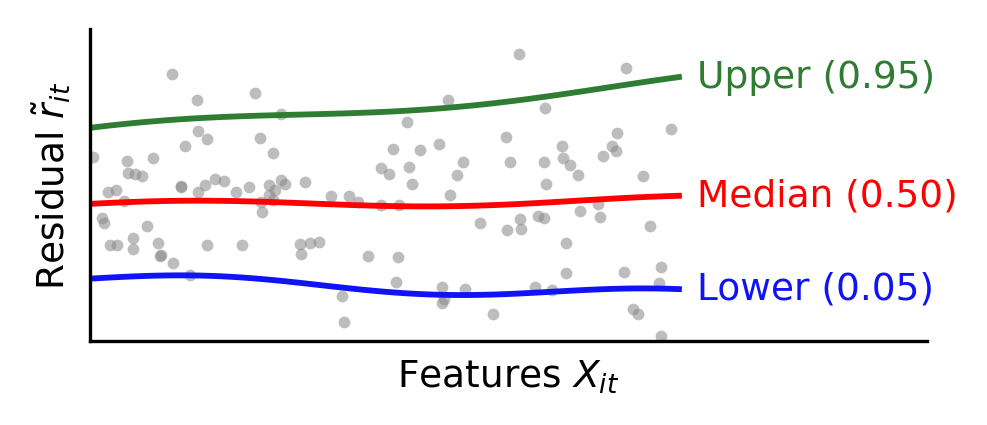

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

blue = "#1013F6"
red = "#FF0000"
green = "#2E7D32"
gray = "#888888"

n = 55
x = np.linspace(0, 1, n)

# Three residual bands with natural variation
lower = -0.35 - 0.08 * x + 0.03 * np.sin(8 * x)
median = 0.00 + 0.03 * x + 0.02 * np.sin(7 * x + 0.5)
upper = 0.35 + 0.25 * x + 0.03 * np.sin(6 * x + 1.0)

# Scattered residuals around the conditional distribution
x_scatter = np.random.uniform(0, 1, 120)
center = 0.02 + 0.02 * x_scatter
spread = 0.22 + 0.20 * x_scatter
y_scatter = center + spread * np.random.randn(120)

fig, ax = plt.subplots(figsize=(3.6, 1.35), dpi=300)

ax.scatter(
    x_scatter,
    y_scatter,
    s=8,
    color=gray,
    alpha=0.55,
    linewidths=0
)

ax.plot(x, upper, color=green, linewidth=1.4)
ax.plot(x, median, color=red, linewidth=1.4)
ax.plot(x, lower, color=blue, linewidth=1.4)

ax.text(1.03, upper[-1], "Upper (0.95)", color=green, fontsize=9, va="center")
ax.text(1.03, median[-1], "Median (0.50)", color=red, fontsize=9, va="center")
ax.text(1.03, lower[-1], "Lower (0.05)", color=blue, fontsize=9, va="center")

ax.set_xlabel(r"Features $X_{it}$", fontsize=9)
ax.set_ylabel(r"Residual $\tilde{r}_{it}$", fontsize=9)

ax.set_xlim(0, 1.42)
ax.set_ylim(-0.65, 0.85)
ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("quantile_regression_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

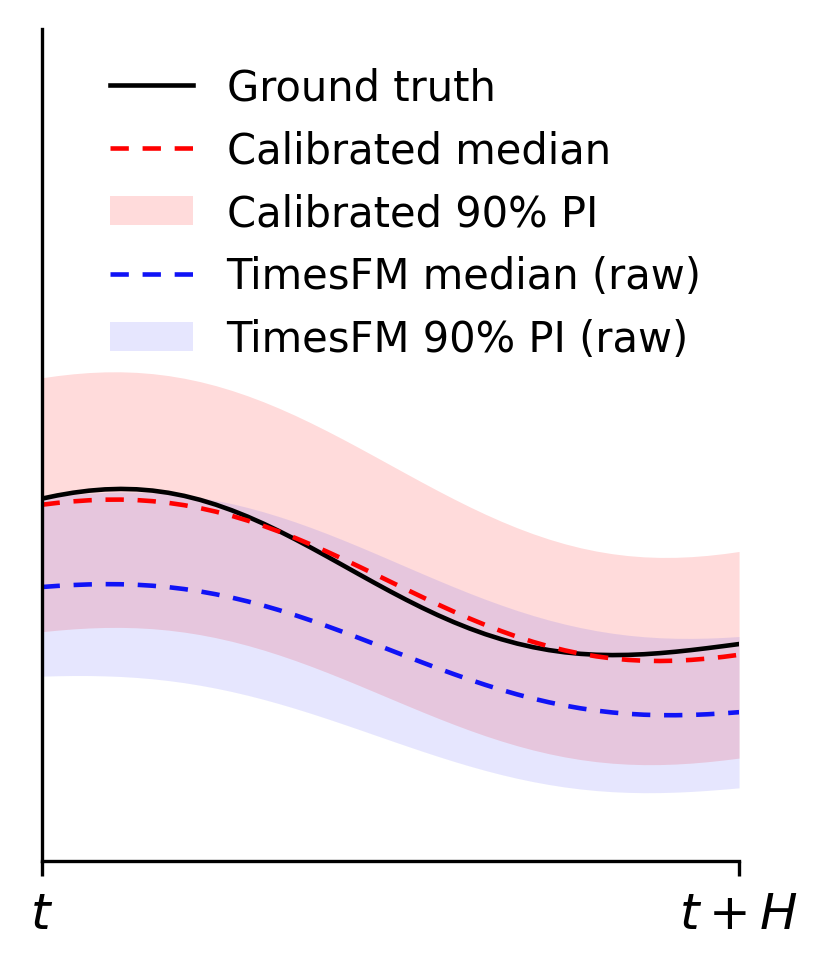

In [11]:
import numpy as np
import matplotlib.pyplot as plt

blue = "#1013F6"
red = "#FF0000"
black = "#000000"

T = 45
x = np.arange(T)

raw_mean = 0.43 - 0.0015 * x + 0.020 * np.sin(x / 8.0 + 0.4)
cal_mean = raw_mean + 0.045 + 0.010 * np.sin(x / 10.0 + 1.0)

ground_truth = cal_mean + 0.007 * np.sin(x / 6.0 + 0.6)

raw_width = 0.055 + 0.006 * np.sin(x / 11.0 + 0.5)
cal_width = 0.075 + 0.008 * np.sin(x / 12.0 + 1.2)

raw_lower = raw_mean - raw_width
raw_upper = raw_mean + raw_width
cal_lower = cal_mean - cal_width
cal_upper = cal_mean + cal_width

fig, ax = plt.subplots(figsize=(3, 3.6), dpi=300)

ax.fill_between(x, cal_lower, cal_upper, color=red, alpha=0.14, linewidth=0, label="Calibrated 90% PI")
ax.fill_between(x, raw_lower, raw_upper, color=blue, alpha=0.10, linewidth=0, label="TimesFM 90% PI (raw)")

ax.plot(x, ground_truth, color=black, linewidth=1.1, label="Ground truth")
ax.plot(x, cal_mean, color=red, linewidth=1.1, linestyle=(0, (4, 3)), label="Calibrated median")
ax.plot(x, raw_mean, color=blue, linewidth=1.1, linestyle=(0, (4, 3)), label="TimesFM median (raw)")

handles, labels = ax.get_legend_handles_labels()
order = [2, 3, 0, 4, 1]

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc="upper right",
    frameon=False,
    fontsize=10,
    ncol=1
)

ax.set_xlim(0, T - 1)
ax.set_ylim(0.26, 0.8)

ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H$"], fontsize=12)
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(
    "calibrated_vs_raw_forecast_with_ground_truth.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

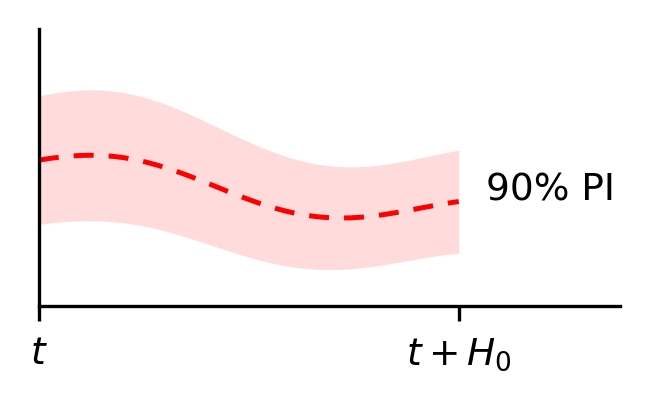

In [12]:
import numpy as np
import matplotlib.pyplot as plt

red = "#FF0000"

T = 40
x = np.arange(T)

mean = (
    0.50
    - 0.0015 * x
    + 0.025 * np.sin(x / 6.0 + 0.4)
)

width = 0.075 + 0.010 * np.sin(x / 9.0 + 1.0)

lower = mean - width
upper = mean + width

fig, ax = plt.subplots(figsize=(2.5, 1.2), dpi=300)

ax.fill_between(
    x, lower, upper,
    color=red,
    alpha=0.14,
    linewidth=0
)

ax.plot(
    x, mean,
    color=red,
    linewidth=1.2,
    linestyle=(0, (4, 3))
)

ax.text(
    T + 1.5,
    np.mean(mean),
    "90% PI",
    ha="left",
    va="center",
    fontsize=9
)

ax.set_xlim(0, T + 14)
ax.set_ylim(0.32, 0.68)

ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H_0$"], fontsize=9)
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("pre_policy_counterfactual_pi.png", dpi=300, bbox_inches="tight")
plt.show()

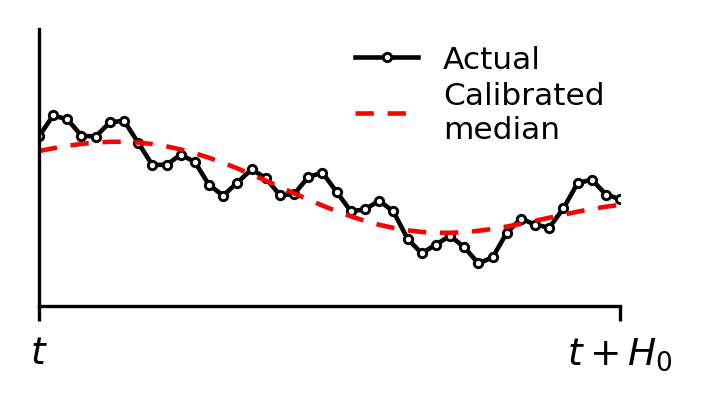

In [13]:
import numpy as np
import matplotlib.pyplot as plt

red = "#FF0000"
black = "#000000"

T = 42
x = np.arange(T)

median = (
    0.52
    - 0.0020 * x
    + 0.035 * np.sin(x / 6.0 + 0.3)
)

actual = (
    median
    + 0.025 * np.sin(x / 3.0 + 0.8)
    + 0.018 * np.sin(1.35 * x)
)

fig, ax = plt.subplots(figsize=(2.5, 1.2), dpi=300)

ax.plot(
    x, actual,
    color=black,
    linewidth=1.1,
    marker="o",
    markersize=2.0,
    markerfacecolor="white",
    markeredgewidth=0.7,
    label="Actual"
)

ax.plot(
    x, median,
    color=red,
    linewidth=1.1,
    linestyle=(0, (4, 3)),
    label="Calibrated\nmedian"
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=7.5,
    handlelength=2.0,
    labelspacing=0.25,
    borderaxespad=0.1
)

ax.set_xlim(0, T - 1)
ax.set_ylim(0.34, 0.68)

ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H_0$"], fontsize=9)
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("compare_actual_calibrated_median.png", dpi=300, bbox_inches="tight")
plt.show()

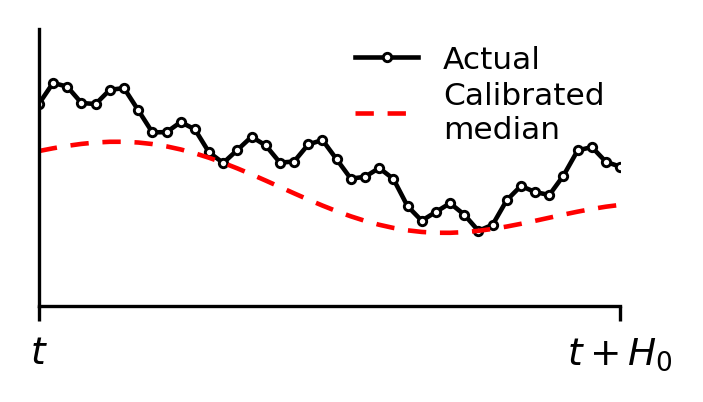

In [14]:
import numpy as np
import matplotlib.pyplot as plt

red = "#FF0000"
black = "#000000"

T = 42
x = np.arange(T)

median = (
    0.52
    - 0.0020 * x
    + 0.035 * np.sin(x / 6.0 + 0.3)
)

actual = (
    median
    + 0.04
    + 0.025 * np.sin(x / 3.0 + 0.8)
    + 0.018 * np.sin(1.35 * x)
)

fig, ax = plt.subplots(figsize=(2.5, 1.2), dpi=300)

ax.plot(
    x, actual,
    color=black,
    linewidth=1.1,
    marker="o",
    markersize=2.0,
    markerfacecolor="white",
    markeredgewidth=0.7,
    label="Actual"
)

ax.plot(
    x, median,
    color=red,
    linewidth=1.1,
    linestyle=(0, (4, 3)),
    label="Calibrated\nmedian"
)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=7.5,
    handlelength=2.0,
    labelspacing=0.25,
    borderaxespad=0.1
)

ax.set_xlim(0, T - 1)
ax.set_ylim(0.34, 0.68)

ax.set_xticks([0, T - 1])
ax.set_xticklabels([r"$t$", r"$t+H_0$"], fontsize=9)
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("compare_actual_calibrated_median.png", dpi=300, bbox_inches="tight")
plt.show()